# EDA: Mesogeos Track A (wildfire danger forecasting)

Data: `data/raw/track_a/{positives,negatives}.csv` (run `python -m forest_fire_risk.download_data`),
loaded with `forest_fire_risk.data.load_track_a`. Each **sample is a 30-day sequence** (30 rows,
`time_idx` 0..29) for one 1 km grid cell. Positives: day 29 is a fire day (burned
area from EFFIS). Negatives: random non-fire cell/date, sampled with the same
seasonal/geographic distribution as positives.

Columns: `time`, `x` (lon), `y` (lat), `sample` (sequence id), `time_idx`,
12 dynamic drivers (change daily), 14 static drivers (constant per cell), and
3 label/leakage columns (`burned_areas`, `ignition_points`, `burned_area_has`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parent
DATA = ROOT / "data" / "raw" / "track_a"
OUT = ROOT / "reports" / "eda"
OUT.mkdir(parents=True, exist_ok=True)

FIRE, NOFIRE = "#eb6834", "#2a78d6"   # categorical slots 2 and 1
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold"})

from forest_fire_risk.data import load_track_a, DYNAMIC, STATIC

df = load_track_a(DATA).rename(columns={"sample_id": "sample"})
pos, neg = df[df.label == 1], df[df.label == 0]
print(f"rows={len(df):,}  samples={df['sample'].nunique():,}  positives={pos['sample'].nunique():,}  negatives={neg['sample'].nunique():,}")
print("dynamic:", DYNAMIC)
print("static:", STATIC)

rows=777,480  samples=25,916  positives=8,574  negatives=17,342
dynamic: ['d2m', 'lai', 'lst_day', 'lst_night', 'ndvi', 'rh', 'smi', 'sp', 'ssrd', 't2m', 'tp', 'wind_direction', 'wind_speed']
static: ['aspect', 'curvature', 'dem', 'roads_distance', 'slope', 'lc_agriculture', 'lc_forest', 'lc_grassland', 'lc_settlement', 'lc_shrubland', 'lc_sparse_vegetation', 'lc_water_bodies', 'lc_wetland', 'population']


## 1. Structure checks

In [2]:
assert (df.groupby("sample").size() == 30).all(), "every sample must have 30 rows"
assert (df.groupby("sample")[STATIC].nunique().max() == 1).all(), "static features must be constant within a sample"
last = df[df.time_idx == 29].set_index("sample")          # one row per sample = the "forecast day"
print("date range:", df.time.min().date(), "->", df.time.max().date())
print("lon:", round(df.x.min(), 2), round(df.x.max(), 2), " lat:", round(df.y.min(), 2), round(df.y.max(), 2))
print(f"class balance (samples): fire={last.label.sum():,}  no-fire={(1-last.label).sum():,}  ratio 1:{(1-last.label).sum()/last.label.sum():.2f}")

date range: 2006-04-01 -> 2022-09-29
lon: -9.76 36.1  lat: 30.7 45.97
class balance (samples): fire=8,574  no-fire=17,342  ratio 1:2.02


## 2. Label / leakage columns
`burned_areas`, `ignition_points` and `burned_area_has` *are* the target. They must
be dropped from the feature set (the Mesogeos baselines do this too).

positives, day 29: burned_areas>0 = 67.2%  ignition_points>0 = 25.3%
positives, days 0-28: any burned_areas>0 = 1.6%
negatives, any day: any burned_areas>0 = 0.07%
burned_area_has (ha) for positives:
count      8574.0
mean        570.0
std        2409.0
min          30.0
25%          72.0
50%         148.0
75%         382.0
max      107602.0
Name: burned_area_has, dtype: float64


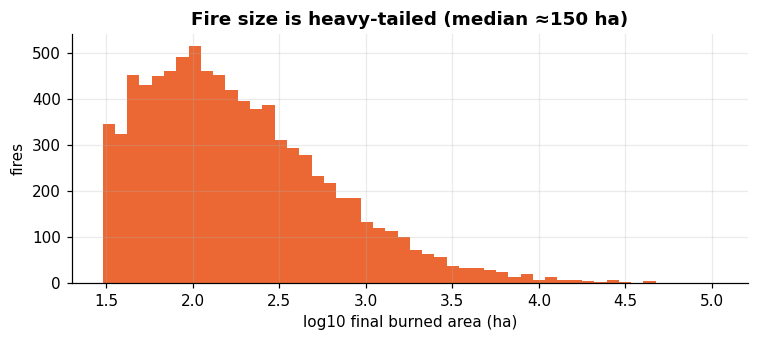

In [3]:
print("positives, day 29: burned_areas>0 =", f"{(last.loc[last.label==1,'burned_areas']>0).mean():.1%}",
      " ignition_points>0 =", f"{(last.loc[last.label==1,'ignition_points']>0).mean():.1%}")
print("positives, days 0-28: any burned_areas>0 =",
      f"{(df[(df.label==1)&(df.time_idx<29)].groupby('sample').burned_areas.max()>0).mean():.1%}")
print("negatives, any day: any burned_areas>0 =",
      f"{(df[df.label==0].groupby('sample').burned_areas.max()>0).mean():.2%}")
print("burned_area_has (ha) for positives:")
print(last.loc[last.label == 1, "burned_area_has"].describe().round(0))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(np.log10(last.loc[last.label == 1, "burned_area_has"]), bins=50, color=FIRE)
ax.set(xlabel="log10 final burned area (ha)", ylabel="fires", title="Fire size is heavy-tailed (median ≈150 ha)")
fig.tight_layout(); fig.savefig(OUT / "01_fire_size.png")

## 3. Temporal distribution

time   2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  \
label                                                                           
0       251  1193   441   852   799  1515  1707   638   556   642   723  2365   
1       143   584   217   418   396   747   840   311   273   317   360  1162   
total   394  1777   658  1270  1195  2262  2547   949   829   959  1083  3527   

time   2018  2019  2020  2021  2022  
label                                
0       362  1009  1538  1490  1261  
1       183   500   754   734   635  
total   545  1509  2292  2224  1896  
2017–2022: {'no fire': 8025, 'fire': 3968}


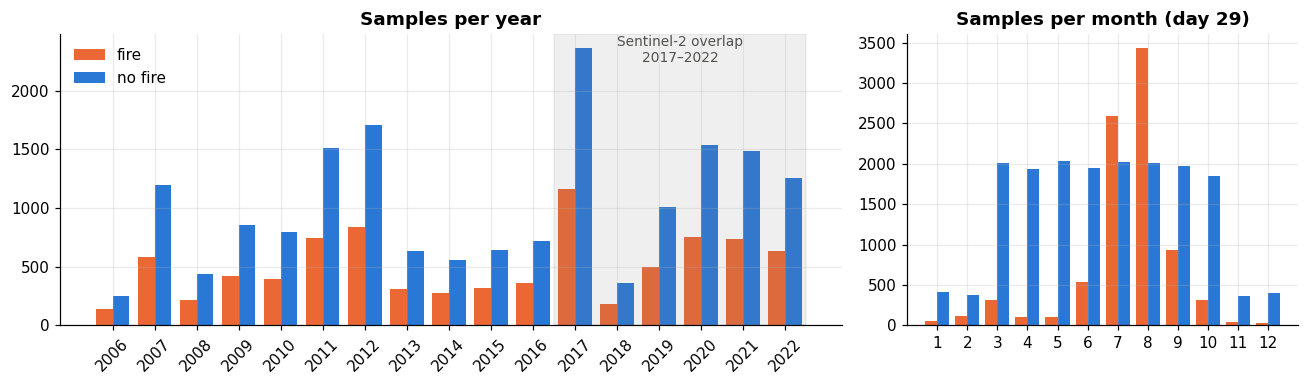

In [4]:
yr = last.groupby([last.time.dt.year, "label"]).size().unstack(fill_value=0)
mo = last.groupby([last.time.dt.month, "label"]).size().unstack(fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [2, 1]})
for ax, tab, title in [(axes[0], yr, "Samples per year"), (axes[1], mo, "Samples per month (day 29)")]:
    x = np.arange(len(tab)); w = 0.4
    ax.bar(x - w/2, tab[1], w, color=FIRE, label="fire")
    ax.bar(x + w/2, tab[0], w, color=NOFIRE, label="no fire")
    ax.set_xticks(x); ax.set_xticklabels(tab.index, rotation=45 if len(tab) > 12 else 0); ax.set_title(title)
axes[0].legend(frameon=False); axes[0].axvspan(10.5, 16.5, color="gray", alpha=0.12)
axes[0].text(13.5, yr.values.max()*0.95, "Sentinel-2 overlap\n2017–2022", ha="center", fontsize=9, color="#52514e")
fig.tight_layout(); fig.savefig(OUT / "02_time.png")
print(yr.assign(total=yr.sum(axis=1)).T)
print("2017–2022:", yr.loc[2017:].sum().rename({1: "fire", 0: "no fire"}).to_dict())

## 4. Geography

label           no fire  fire
region                       
Italy              2699  3448
Portugal           1624  1575
Greece/Balkans     2694  1402
Spain              4828   951
N. Africa          2645   570
other               756   402
Turkey             1480   141
France              616    85


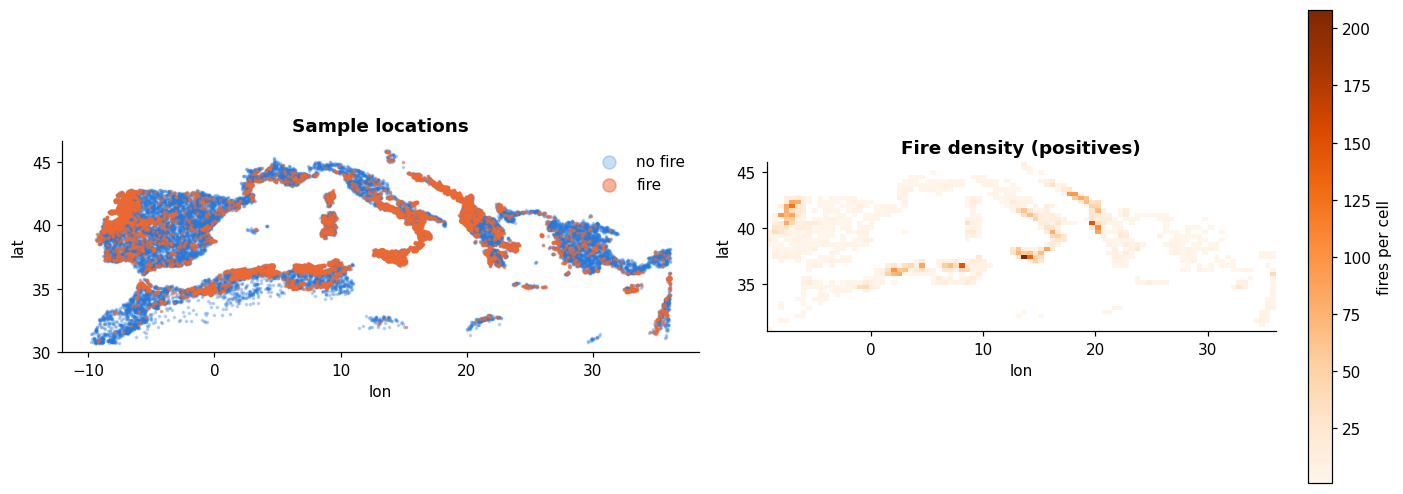

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
n0 = last[last.label == 0]; n1 = last[last.label == 1]
axes[0].scatter(n0.x, n0.y, s=2, color=NOFIRE, alpha=0.25, label="no fire")
axes[0].scatter(n1.x, n1.y, s=2, color=FIRE, alpha=0.5, label="fire")
axes[0].set(title="Sample locations", xlabel="lon", ylabel="lat"); axes[0].legend(frameon=False, markerscale=6)
h = axes[1].hist2d(n1.x, n1.y, bins=[90, 40], cmap="Oranges", cmin=1)
fig.colorbar(h[3], ax=axes[1], label="fires per cell")
axes[1].set(title="Fire density (positives)", xlabel="lon", ylabel="lat")
for ax in axes: ax.set_aspect("equal"); ax.grid(False)
fig.tight_layout(); fig.savefig(OUT / "03_geo.png")

# rough country buckets by lon/lat boxes, for a geographic split later
def region(r):  # ponytail: lon/lat boxes, swap for the Ecoregions/country shapefile if a clean split matters
    if r.y < 36.0 and r.x < 12: return "N. Africa"
    if r.x < -6 and r.y > 36.5: return "Portugal"
    if r.x < 3.5 and r.y > 35.5 and r.y < 44: return "Spain"
    if 3.5 <= r.x < 8 and r.y >= 42: return "France"
    if 6.5 <= r.x < 19 and r.y > 36 and r.y <= 47: return "Italy"
    if 19 <= r.x < 29 and r.y > 34: return "Greece/Balkans"
    if r.x >= 26 and r.y > 35.5: return "Turkey"
    return "other"
last["region"] = last.apply(region, axis=1)
print(last.groupby(["region", "label"]).size().unstack(fill_value=0).rename(columns={1: "fire", 0: "no fire"}).sort_values("fire", ascending=False))

## 5. Missing values
LST (MODIS, cloud-masked) and soil moisture have the most gaps. Negatives have more
LST gaps than positives (fire days are cloud-free by construction). A model that
learns "missing LST => no fire" is learning the sampling artifact, so impute
before training (the baselines use the per-sequence mean).

label       no fire   fire
lst_night     0.414  0.253
lst_day       0.371  0.192
smi           0.130  0.106
lai           0.020  0.011
ndvi          0.003  0.001
population    0.000  0.000


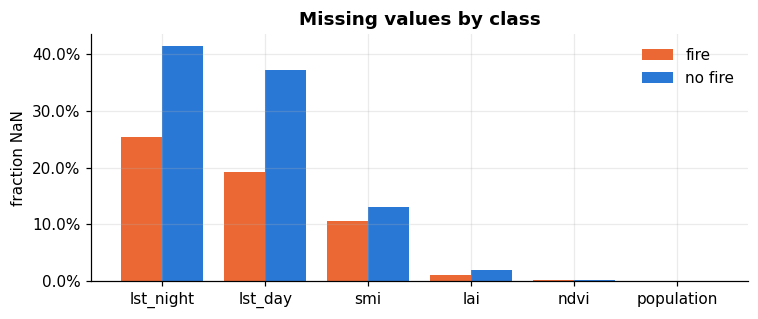

In [6]:
na = df.groupby("label")[DYNAMIC + STATIC].apply(lambda g: g.isna().mean()).T
na = na[(na > 0).any(axis=1)].rename(columns={1: "fire", 0: "no fire"}).sort_values("fire", ascending=False)
fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(na)); w = 0.4
ax.bar(x - w/2, na["fire"], w, color=FIRE, label="fire"); ax.bar(x + w/2, na["no fire"], w, color=NOFIRE, label="no fire")
ax.set_xticks(x); ax.set_xticklabels(na.index); ax.set(ylabel="fraction NaN", title="Missing values by class")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0)); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "04_missing.png")
print(na.round(3))

## 6. Dynamic drivers on the forecast day (fire vs no fire)

rh                     -0.81
smi                    -0.73
tp                     -0.46
dem                    -0.20
lc_sparse_vegetation   -0.16
lc_shrubland           -0.15
lc_agriculture         -0.13
roads_distance         -0.10
lc_water_bodies        -0.04
population             -0.02
aspect                 -0.02
ndvi                   -0.01
wind_direction         -0.01
lc_settlement           0.01
wind_speed              0.02
lai                     0.05
curvature               0.09
lc_wetland              0.10
lc_forest               0.17
lc_grassland            0.23
slope                   0.26
sp                      0.30
d2m                     0.59
ssrd                    0.67
lst_day                 0.68
lst_night               0.84
t2m                     0.95
dtype: float64


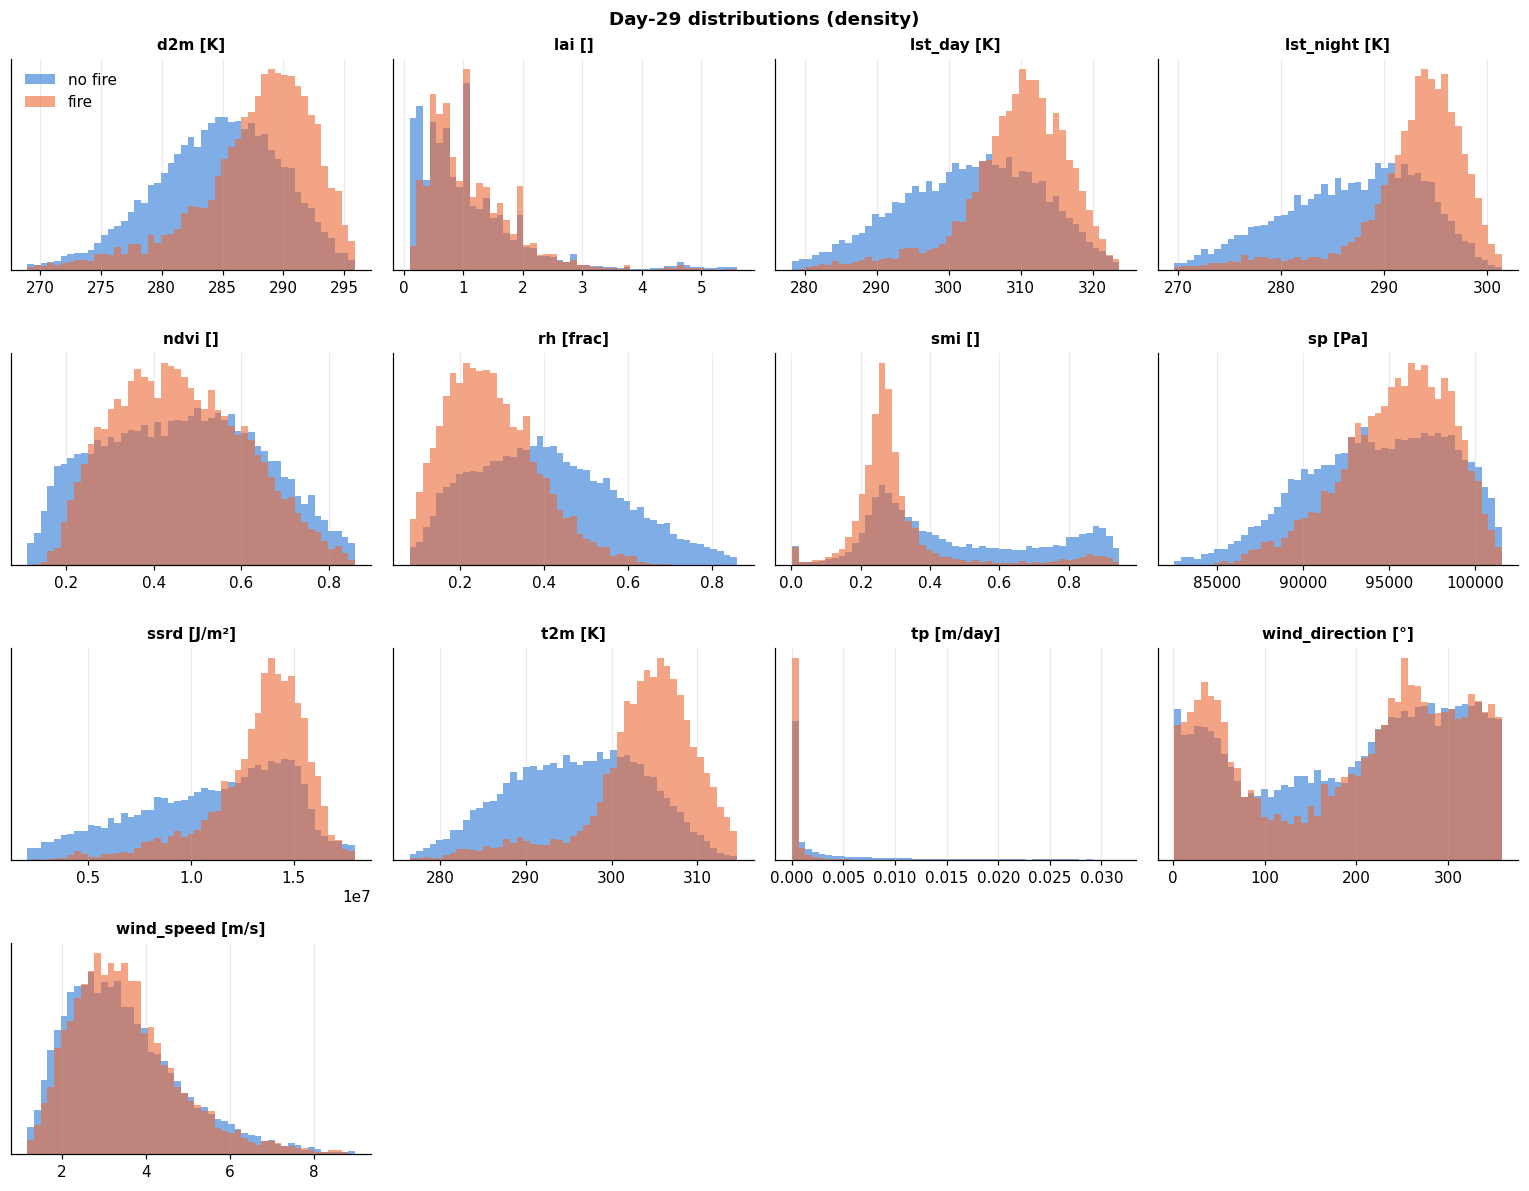

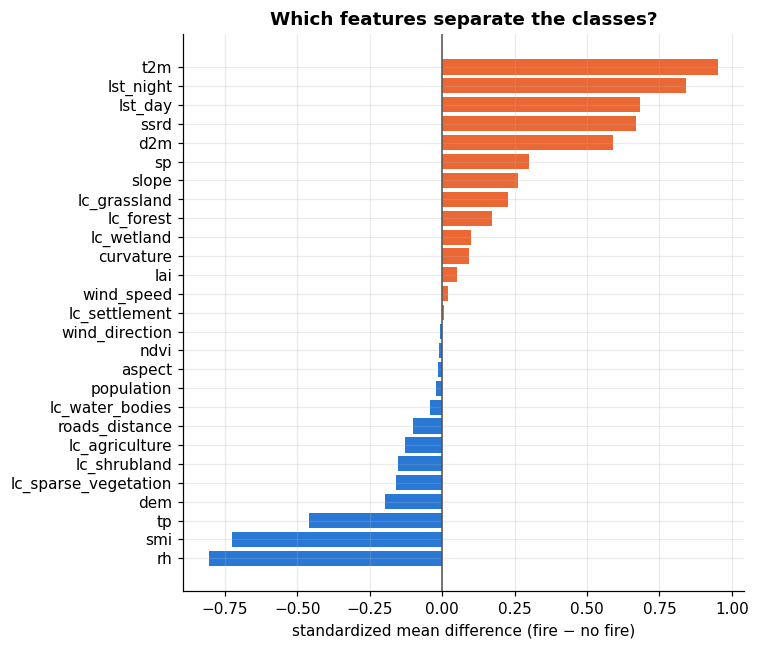

In [7]:
UNITS = {"t2m": "K", "d2m": "K", "rh": "frac", "tp": "m/day", "sp": "Pa", "ssrd": "J/m²", "wind_speed": "m/s",
         "wind_direction": "°", "lst_day": "K", "lst_night": "K", "ndvi": "", "lai": "", "smi": ""}
fig, axes = plt.subplots(4, 4, figsize=(14, 11)); axes = axes.ravel()
for ax in axes[len(DYNAMIC):]: ax.axis("off")
for ax, v in zip(axes, DYNAMIC):
    a, b = last.loc[last.label == 1, v].dropna(), last.loc[last.label == 0, v].dropna()
    lo, hi = np.nanpercentile(pd.concat([a, b]), [0.5, 99.5]); bins = np.linspace(lo, hi, 50)
    ax.hist(b, bins, density=True, color=NOFIRE, alpha=0.6, label="no fire")
    ax.hist(a, bins, density=True, color=FIRE, alpha=0.6, label="fire")
    ax.set_title(f"{v} [{UNITS.get(v, '')}]", fontsize=10); ax.set_yticks([])
axes[0].legend(frameon=False)
fig.suptitle("Day-29 distributions (density)", fontweight="bold"); fig.tight_layout(); fig.savefig(OUT / "05_dynamic_day29.png")

# standardized mean difference, a quick univariate "how separable" score
smd = ((last[last.label == 1][DYNAMIC + STATIC].mean() - last[last.label == 0][DYNAMIC + STATIC].mean())
       / last[DYNAMIC + STATIC].std()).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(smd.index, smd.values, color=[FIRE if s > 0 else NOFIRE for s in smd.values])
ax.axvline(0, color="#52514e", lw=1); ax.set(xlabel="standardized mean difference (fire − no fire)", title="Which features separate the classes?")
fig.tight_layout(); fig.savefig(OUT / "06_smd.png")
print(smd.round(2))

## 7. The 30-day run-up: do drivers build toward the fire day?

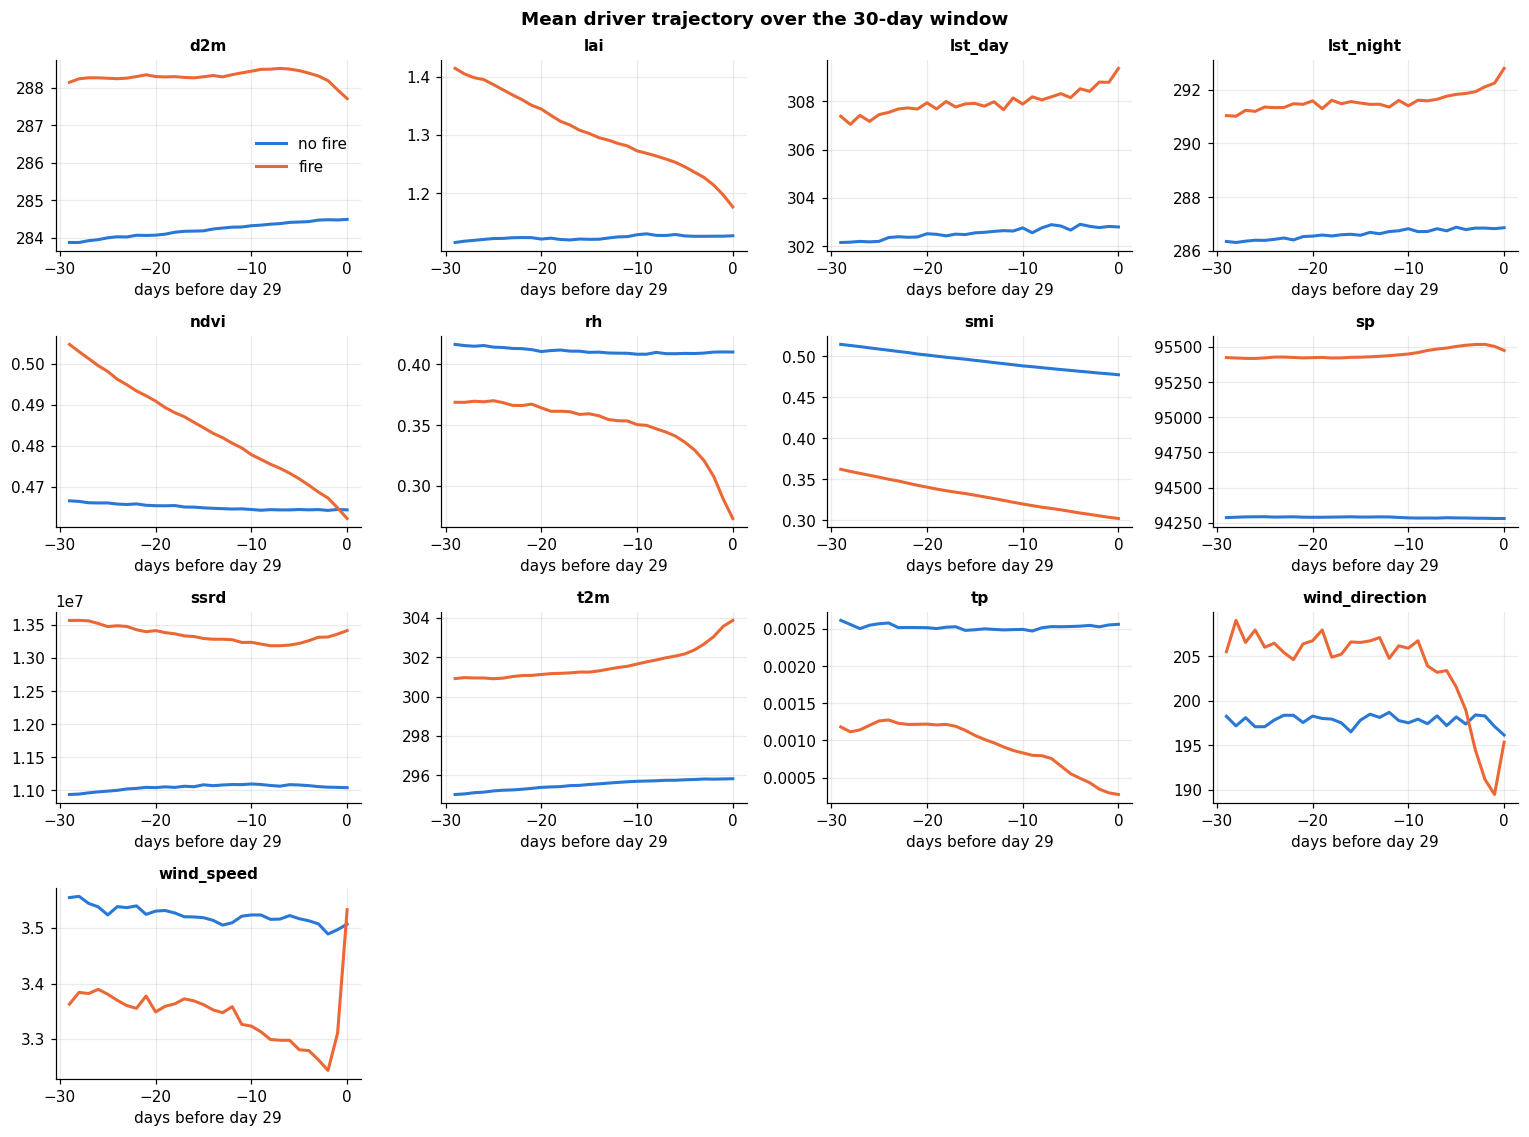

In [8]:
prof = df.groupby(["label", "time_idx"])[DYNAMIC].mean()
fig, axes = plt.subplots(4, 4, figsize=(14, 10.5)); axes = axes.ravel()
for ax in axes[len(DYNAMIC):]: ax.axis("off")
for ax, v in zip(axes, DYNAMIC):
    ax.plot(prof.loc[0, v].index - 29, prof.loc[0, v].values, color=NOFIRE, lw=2, label="no fire")
    ax.plot(prof.loc[1, v].index - 29, prof.loc[1, v].values, color=FIRE, lw=2, label="fire")
    ax.set_title(v, fontsize=10); ax.set_xlabel("days before day 29")
axes[0].legend(frameon=False)
fig.suptitle("Mean driver trajectory over the 30-day window", fontweight="bold"); fig.tight_layout(); fig.savefig(OUT / "07_trajectories.png")

## 8. Static drivers (land cover, terrain, human)

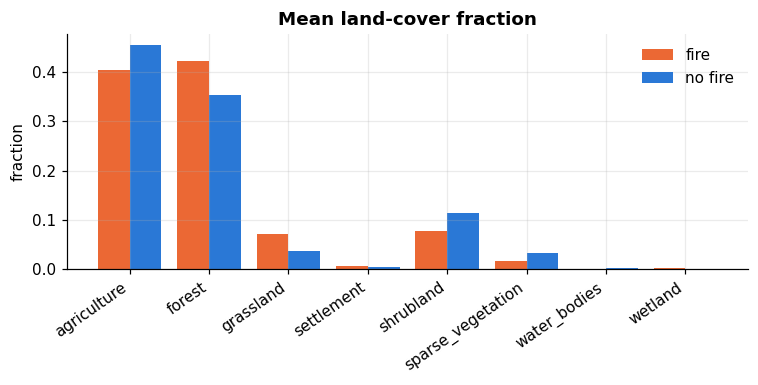

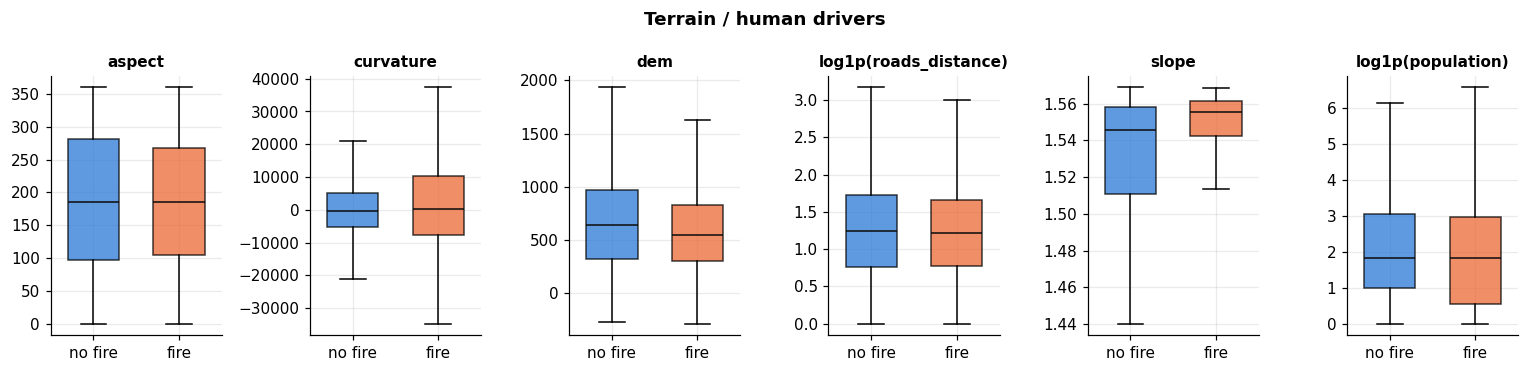

In [9]:
LC = [s for s in STATIC if s.startswith("lc_")]
OTHER = [s for s in STATIC if s not in LC]
fig, ax0 = plt.subplots(figsize=(7, 3.6)); axes = [ax0]
lc = last.groupby("label")[LC].mean().T.rename(columns={1: "fire", 0: "no fire"})
x = np.arange(len(lc)); w = 0.4
axes[0].bar(x - w/2, lc["fire"], w, color=FIRE, label="fire"); axes[0].bar(x + w/2, lc["no fire"], w, color=NOFIRE, label="no fire")
axes[0].set_xticks(x); axes[0].set_xticklabels([c[3:] for c in lc.index], rotation=35, ha="right")
axes[0].set(title="Mean land-cover fraction", ylabel="fraction"); axes[0].legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "08_static_landcover.png")

fig, axes = plt.subplots(1, len(OTHER), figsize=(14, 3.4))
for ax, v in zip(axes, OTHER):
    a, b = last.loc[last.label == 1, v].dropna(), last.loc[last.label == 0, v].dropna()
    if v in ("population", "roads_distance"):
        a, b = np.log1p(a), np.log1p(b); v = f"log1p({v})"
    bp = ax.boxplot([b, a], widths=0.6, showfliers=False, patch_artist=True, medianprops={"color": "#0b0b0b"})
    for patch, c in zip(bp["boxes"], [NOFIRE, FIRE]): patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["no fire", "fire"]); ax.set_title(v, fontsize=10)
fig.suptitle("Terrain / human drivers", fontweight="bold")
fig.tight_layout(); fig.savefig(OUT / "08_static_terrain.png")

## 9. Feature correlation (day-29 rows)

|r| > 0.7:
lst_night       t2m          0.91
sp              dem         -0.90
lst_day         t2m          0.86
                lst_night    0.84
d2m             lst_night    0.77
lai             ndvi         0.74
lc_agriculture  lc_forest   -0.73
rh              t2m         -0.72
d2m             t2m          0.70
dtype: float64


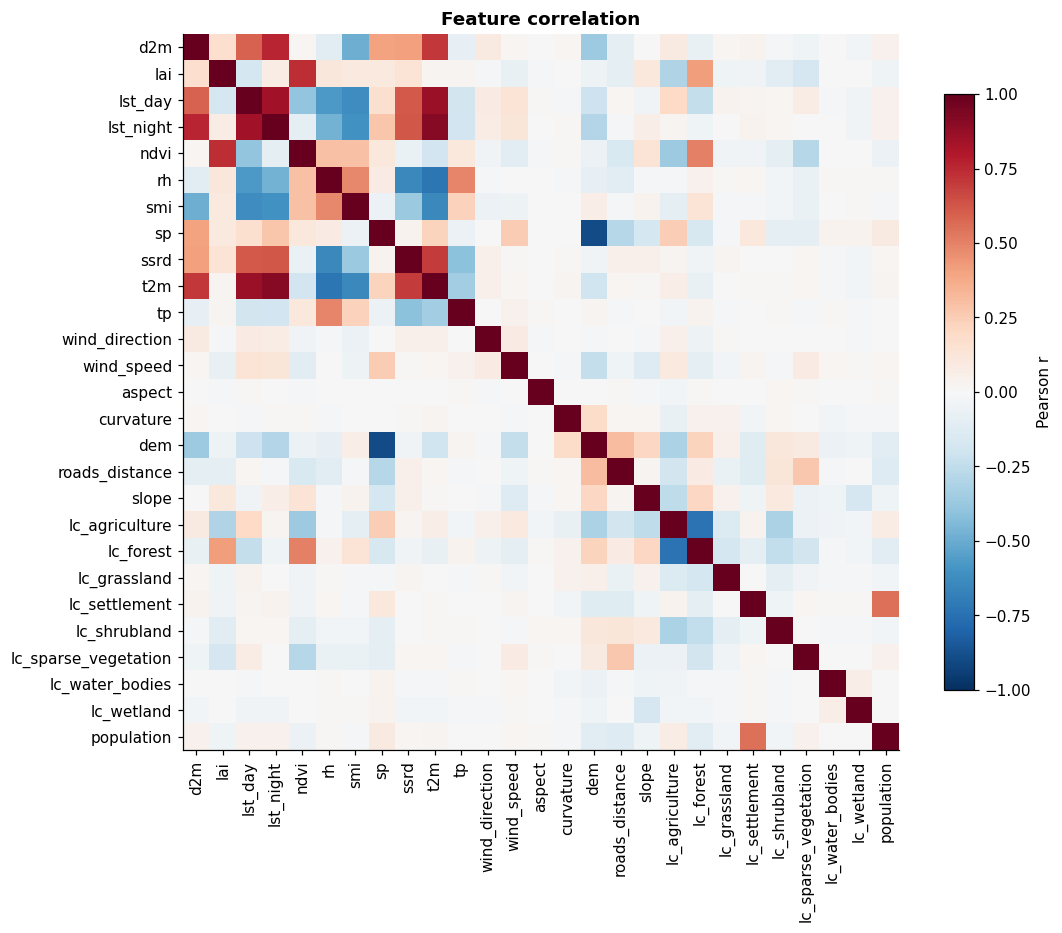

In [10]:
corr = last[DYNAMIC + STATIC].corr()
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90); ax.set_yticklabels(corr.columns); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r"); ax.set_title("Feature correlation")
fig.tight_layout(); fig.savefig(OUT / "09_corr.png")
pairs = corr.where(np.triu(np.ones_like(corr, dtype=bool), 1)).stack()
print("|r| > 0.7:"); print(pairs[pairs.abs() > 0.7].sort_values(key=abs, ascending=False).round(2))

## 10. Takeaways
* **26k samples** (8,574 fire / 17,342 no-fire, ratio 1:2), 2006–2022, whole Mediterranean. Each sample = 30 daily rows × 12 dynamic + 14 static drivers.
* **Drop `burned_areas`, `ignition_points`, `burned_area_has` from X** – they encode the label.
* **Sentinel-2 overlap (2017–2022): ~4k fires / ~8k non-fires** – plenty for the CNN branch.
* Fire days are hotter and drier (`t2m`, `lst_*`, `ssrd` up; `rh`, `smi`, `tp` down). Wind speed barely differs. The gap widens over the last ~10 days of the window, so the sequence carries signal beyond day 29 alone.
* **Negatives are not season-matched**: they are spread evenly over Mar–Oct while fires peak Jul–Aug. A model can score well just by learning 'hot month'. Consider resampling negatives to the fire month distribution for a fairer test.
* `slope` values sit in 1.44–1.57 for almost all cells – looks mis-scaled in the extraction; use with care or recompute from `dem`.
* Fires sit on forest/grassland and steeper slopes; negatives skew to agriculture, shrubland and sparse vegetation. Population and road distance barely differ (negatives were sampled to match).
* Missingness differs by class (LST) → impute, don't let the model see NaN-ness.
* Splits: by year (2017–2020 train / 2021–2022 test, matches Mesogeos) or by region column above; never random by row (30 rows per sample are near-duplicates).